# **NLP 1 - Intro to text mining & Natural Language Processing**

## Challenge

- Importe NLTK et télécharge les fonctions dont tu auras besoin (au fur et à mesure si nécessaire).
- Récupère le texte d'un article de presse de ton choix sur internet (en anglais ce sera plus simple, mais tu peux prendre la langue de ton choix). Affecte-le à une variable via un copier/coller dans ton notebook. Par simplicité pour la suite de cette quête, nous te conseillons de prendre un texte qui fait entre 10 et 30 lignes environ. 
- Transforme ton texte en tokens de phrases
- Transforme ton texte en tokens de mots
- Compte la fréquence d'apparition de chaque mot et réalise un graphique (si possible un diagramme en barre) qui représente les 20 mots les plus présents dans ton texte. Y a-t-il beaucoup de mots qui te semblent être des stopwords ?
- Enlève les stop words et la ponctuation, et regarde à nouveau quels sont les mots les plus présents. Là encore, réalise le même graphique pour comparer.

In [35]:
# ================================================
# 🛜 Import des librairies
# ================================================
import nltk
from nltk.corpus import stopwords
import string
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ================================================
# 🛜 Récupération d'un texte
# ================================================
# Ici on prend l'Abstract du texte sur "Attention is all you need" 
# https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf
text = """The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.0 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature."""

In [3]:
# ================================================
# 🔧 Transformation du texte en tokens de phrases
# ================================================
tokenisation_phrase = nltk.sent_tokenize(text)

In [4]:
# ================================================
# 🔧 Transformation du texte en tokens de mots
# ================================================
tokenisation_mot = nltk.word_tokenize(text)

In [5]:
# ================================================
# 🔢 Décompte de la fréquence d'apparition des 20 premier mots
# ================================================
# On cherche la fréquence d'apparition
freq = nltk.FreqDist(tokenisation_mot)
# On crée un dataframe avec les 20 mots ou caractères les plus fréquents
df = pd.DataFrame(freq.most_common(20), columns=["mot", "occurence"])

In [6]:
df.head()

,mot,occurence
0,the,8
1,",",8
2,.,6
3,on,5
4,models,4


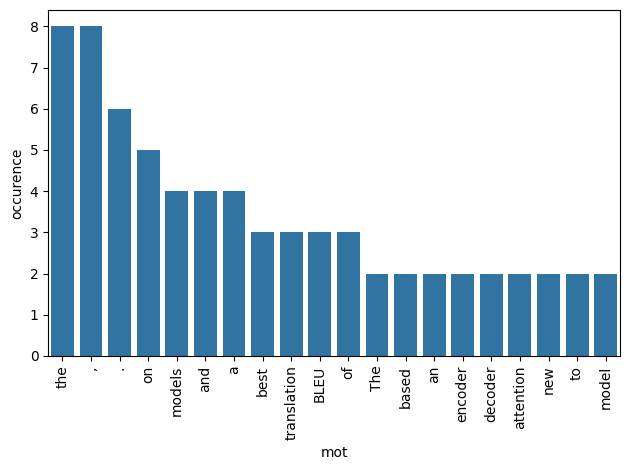

In [7]:
# ================================================
# 📊 Réalisation d'un graphique des 20 premier mots les plus fréquents
# ================================================
sns.barplot(data=df, x='mot', y='occurence')
plt.xticks(rotation=90)
plt.tight_layout()

In [8]:
# ================================================
# 🥽 Vérification du taux d'apparition des Stop Words
# ================================================
stop_words = nltk.corpus.stopwords.words("english")
i = 0
for mot in df.mot:
    if mot in stop_words:
        i += 1
print(f"Sur les {len(df.mot)} mots il y en a {i} qui sont des 'stop words'")
print(f"Ce qui fait un taux de : {int((i*100)/len(df.mot))}%")

Sur les 20 mots il y en a 7 qui sont des 'stop words'
Ce qui fait un taux de : 35%


---

In [9]:
# ================================================
# 🔧 Suppression de la ponctuation et mise en minuscule
# ================================================
def suppressionPonctuationEtMiseEnMinuscule(phrase):
  listeClean = []
  for caractere in phrase:
    if caractere in string.punctuation:
      listeClean.append(" ")
    else:
      listeClean.append(caractere.lower())
  return "".join(listeClean).replace("  ", " ").strip()

clean_text = suppressionPonctuationEtMiseEnMinuscule(text)  

In [17]:
clean_text

'the dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder the best performing models also connect the encoder and decoder through an attention mechanism we propose a new simple network architecture the transformer based solely on attention mechanisms dispensing with recurrence and convolutions entirely experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train our model achieves 28 4 bleu on the wmt 2014 englishto german translation task improving over the existing best results including ensembles by over 2 bleu on the wmt 2014 english to french translation task our model establishes a new single model state of the art bleu score of 41 0 after training for 3 5 days on eight gpus a small fraction of the training costs of the best models from the literature'

In [10]:
# ================================================
# 🔧 Suppression des Stop Words
# ================================================
def suppressionStopWords(phrase):
  listeClean = []
  for mot in phrase.split(" "):
    if mot not in stopwords.words("english"):
      listeClean.append(mot)
  return " ".join(listeClean).replace("  ", " ")

SW_clean_text = suppressionStopWords(clean_text)

In [18]:
SW_clean_text

'dominant sequence transduction models based complex recurrent convolutional neural networks include encoder decoder best performing models also connect encoder decoder attention mechanism propose new simple network architecture transformer based solely attention mechanisms dispensing recurrence convolutions entirely experiments two machine translation tasks show models superior quality parallelizable requiring significantly less time train model achieves 28 4 bleu wmt 2014 englishto german translation task improving existing best results including ensembles 2 bleu wmt 2014 english french translation task model establishes new single model state art bleu score 41 0 training 3 5 days eight gpus small fraction training costs best models literature'

In [11]:
# ================================================
# 🔧 Transformation du texte en tokens de mots
# ================================================
tokenisation_mot_clean = nltk.word_tokenize(SW_clean_text)

In [12]:
# ================================================
# 🔢 Décompte de la fréquence d'apparition des 20 premier mots sans Stop Words
# ================================================
freq_clean = nltk.FreqDist(tokenisation_mot_clean)
df_clean = pd.DataFrame(freq_clean.most_common(20), columns=["mot", "occurence"])

In [13]:
df_clean.head()

,mot,occurence
0,models,4
1,best,3
2,translation,3
3,model,3
4,bleu,3


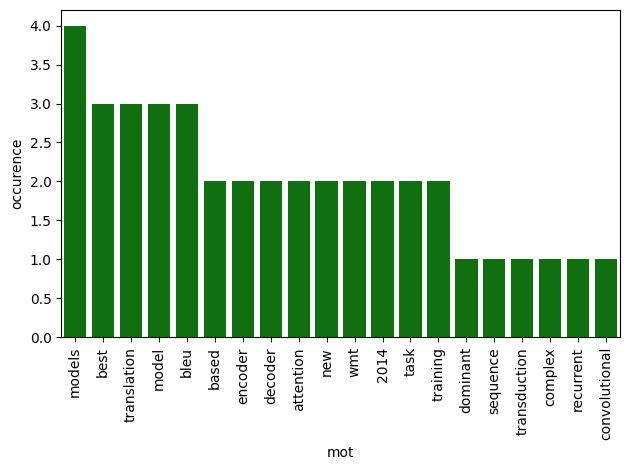

In [14]:
# ================================================
# 📊 Réalisation d'un graphique des 20 premier mots les plus fréquents sans Stop Words
# ================================================
sns.barplot(data=df_clean, x='mot', y='occurence',color='green')
plt.xticks(rotation=90)
plt.tight_layout()

In [15]:
# ================================================
# 🥽 Vérification du taux d'apparition des Stop Words
# ================================================
i = 0
for mot in df_clean.mot:
    if mot in stop_words:
        i += 1
print(f"Sur les {len(df.mot)} mots il y en a {i} qui sont des 'stop words'")
print(f"Ce qui fait un taux de : {int((i*100)/len(df.mot))}%")

Sur les 20 mots il y en a 0 qui sont des 'stop words'
Ce qui fait un taux de : 0%


---
---
# **NLP 2 - Stemming & Lemmatizing**

In [70]:
# ================================================
# 🛜 Vérification du taux d'apparition des Stop Words
# ================================================
from nltk.stem import SnowballStemmer
import spacy

In [22]:
# ================================================
# 🛜 Tokenisation du texte netoyyé
# ================================================
tokenizer = nltk.TreebankWordTokenizer()
tokens = tokenizer.tokenize(SW_clean_text)

## Stemming

In [53]:
# ================================================
# 🪓 Méthode Stemming - 
# ================================================
stem_en = nltk.stem.SnowballStemmer("english")
stemmer_text = " ".join(stem_en.stem(token) for token in tokens)

In [55]:
stemmer_text

'domin sequenc transduct model base complex recurr convolut neural network includ encod decod best perform model also connect encod decod attent mechan propos new simpl network architectur transform base sole attent mechan dispens recurr convolut entir experi two machin translat task show model superior qualiti paralleliz requir signific less time train model achiev 28 4 bleu wmt 2014 englishto german translat task improv exist best result includ ensembl 2 bleu wmt 2014 english french translat task model establish new singl model state art bleu score 41 0 train 3 5 day eight gpus small fraction train cost best model literatur'

In [79]:
# ================================================
# 🔢 Décompte de la fréquence d'apparition des 20 premier mots sans Stop Words
# ================================================
freq_clean = nltk.FreqDist(stemmer_text.split(" "))
df_stem = pd.DataFrame(freq_clean.most_common(20), columns=["mot", "occurence"])

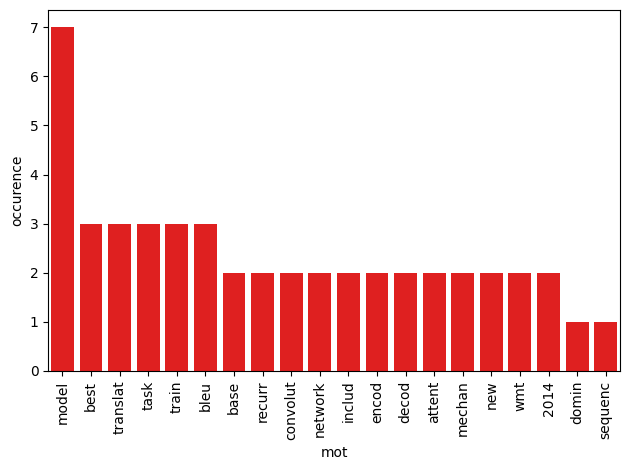

In [80]:
# ================================================
# 📊 Réalisation d'un graphique des 20 premier mots les plus fréquents sans Stop Words
# ================================================
sns.barplot(data=df_stem, x='mot', y='occurence',color='red')
plt.xticks(rotation=90)
plt.tight_layout()

## Lemmatizing

In [44]:
nlp = spacy.load('en_core_web_sm')

In [84]:
# ================================================
# 🔪 Méthode Lemmatizing - 
# ================================================
sent_tokens = nlp(SW_clean_text)
lemma_text = " ".join(token.lemma_ for token in sent_tokens)

In [76]:
lemma_text

'dominant sequence transduction model base complex recurrent convolutional neural network include encoder decoder well perform model also connect encoder decoder attention mechanism propose new simple network architecture transformer base solely attention mechanism dispense recurrence convolution entirely experiment two machine translation task show model superior quality parallelizable require significantly less time train model achieve 28 4 bleu wmt 2014 englishto german translation task improve exist good result include ensemble 2 bleu wmt 2014 english french translation task model establish new single model state art bleu score 41 0 training 3 5 day eight gpu small fraction training cost good model literature'

In [82]:
# ================================================
# 🔢 Décompte de la fréquence d'apparition des 20 premier mots sans Stop Words
# ================================================
freq_clean = nltk.FreqDist(lemma_text.split(" "))
df_lemma = pd.DataFrame(freq_clean.most_common(20), columns=["mot", "occurence"])

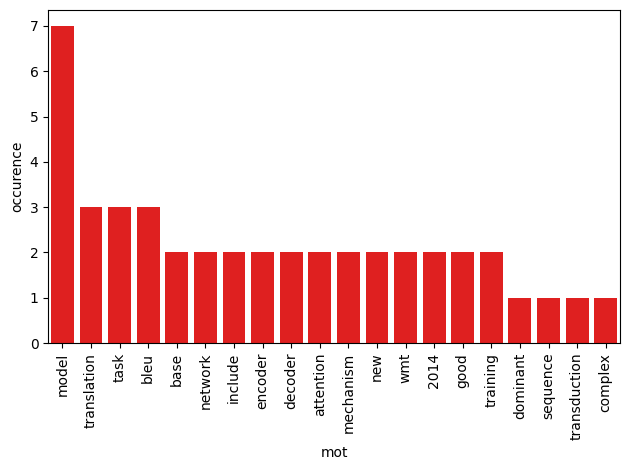

In [83]:
# ================================================
# 📊 Réalisation d'un graphique des 20 premier mots les plus fréquents sans Stop Words
# ================================================
sns.barplot(data=df_lemma, x='mot', y='occurence',color='red')
plt.xticks(rotation=90)
plt.tight_layout()

On voit qu'entre la méthode stemming et la méthode lemmatization, il y a de légère différence sur la fréquence de certains mots.